# Customer Churn Prediction & Intelligent Retention System

**Objective:** Build an end-to-end machine learning pipeline that predicts
which telecom customers are likely to churn, and translate model findings
into an actionable retention strategy.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 raw attributes).

**Sections**
1. Data Loading & Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Model Development & Hyperparameter Tuning
4. Model Evaluation & Business Interpretation


## 1. Data Loading & Exploratory Data Analysis (EDA)

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Publication-quality plotting defaults
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)


ModuleNotFoundError: No module named 'matplotlib'

### 1.1 Load Raw Data

In [ ]:
df_raw = pd.read_csv("Telco-Customer-Churn.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Data Hygiene: the `TotalCharges` edge case

The IBM Telco dataset stores `TotalCharges` as a **string** column, and 11
brand-new customers (all with `tenure == 0`) have a **blank space `" "`**
instead of a numeric value, since they haven't been billed yet. We coerce
this column to numeric and impute the blanks with `0` (their true
lifetime spend to date).


In [ ]:
# How many blank-string TotalCharges are there, and what do they have in common?
blank_mask = df_raw["TotalCharges"].astype(str).str.strip() == ""
print(f"Blank TotalCharges rows: {blank_mask.sum()}")
print("Tenure distribution for those rows:")
print(df_raw.loc[blank_mask, "tenure"].value_counts())


Blank TotalCharges rows: 11
Tenure distribution for those rows:
tenure
0    11
Name: count, dtype: int64


In [ ]:
df = df_raw.copy()
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges dtype after cleaning:", df["TotalCharges"].dtype)
print("Remaining missing values:", df["TotalCharges"].isna().sum())


TotalCharges dtype after cleaning: float64
Remaining missing values: 0


### 1.3 Dataset Assessment

In [ ]:
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)


Shape: (7043, 21)

Missing values per column:
None

Duplicate rows: 0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Visualization 1 — Churn Distribution

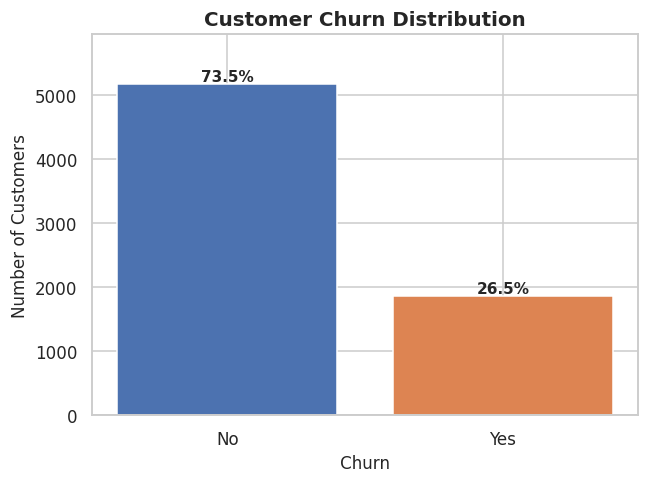

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
churn_counts = df["Churn"].value_counts()
churn_pct = (churn_counts / churn_counts.sum() * 100).round(1)

bars = ax.bar(churn_counts.index, churn_counts.values,
               color=["#4C72B0", "#DD8452"])
for bar, pct in zip(bars, churn_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{pct}%", ha="center", fontweight="bold")

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("plot_01_churn_distribution.png", bbox_inches="tight")
plt.show()


### 1.5 Visualization 2 — Customer Tenure vs Churn

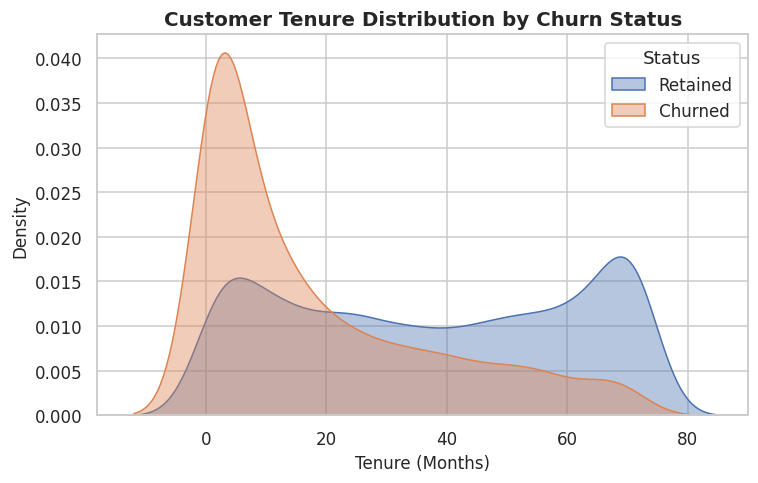

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for churn_val, color, label in [("No", "#4C72B0", "Retained"), ("Yes", "#DD8452", "Churned")]:
    sns.kdeplot(df.loc[df["Churn"] == churn_val, "tenure"], fill=True,
                alpha=0.4, label=label, color=color, ax=ax)

ax.set_title("Customer Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Density")
ax.legend(title="Status")
plt.tight_layout()
plt.savefig("plot_02_tenure_vs_churn.png", bbox_inches="tight")
plt.show()


### 1.6 Visualization 3 — Monthly Charges vs Churn

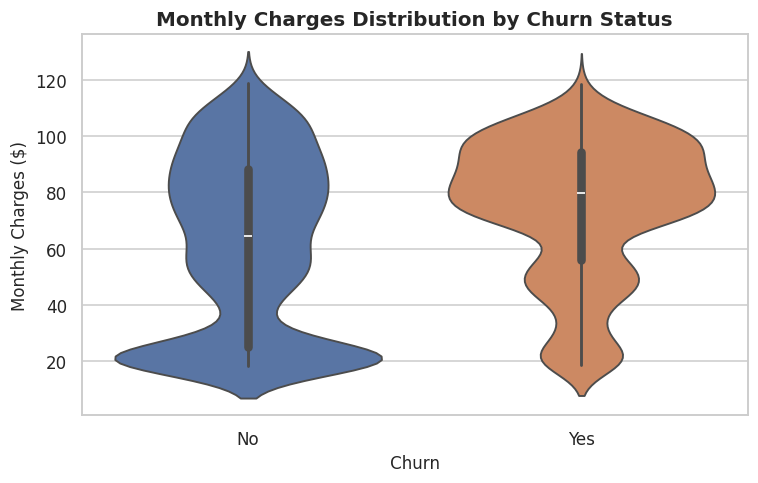

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
                palette={"No": "#4C72B0", "Yes": "#DD8452"}, legend=False, ax=ax)
ax.set_title("Monthly Charges Distribution by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig("plot_03_monthlycharges_vs_churn.png", bbox_inches="tight")
plt.show()


### 1.7 Visualization 4 — Churn Rate by Contract Type & Payment Method

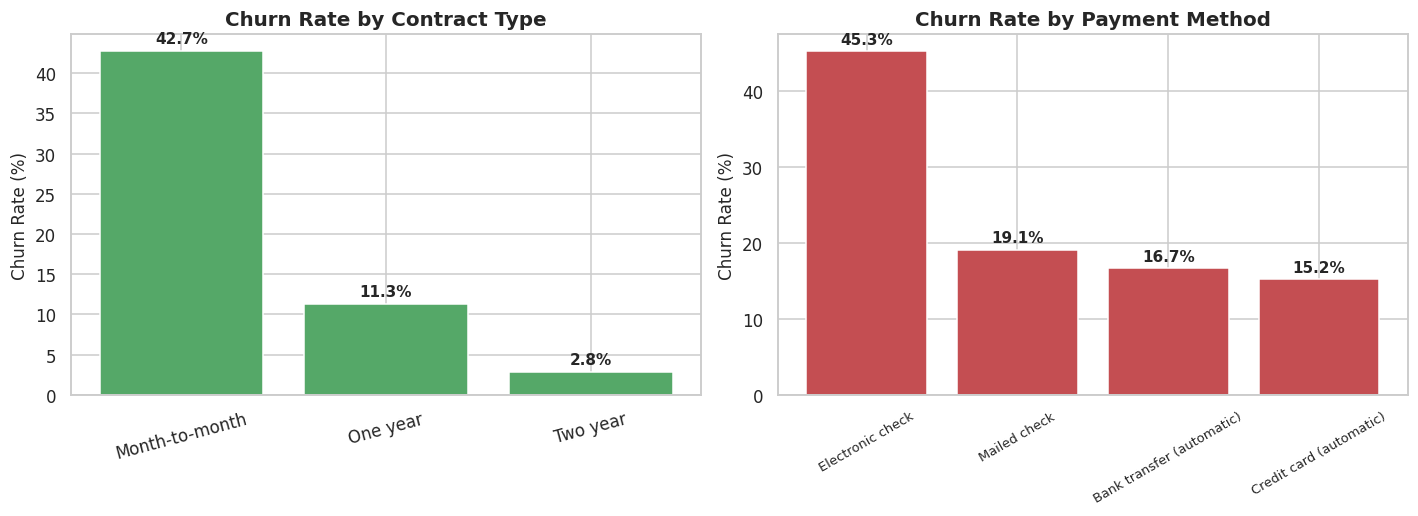

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

contract_churn = (df.groupby("Contract")["Churn"]
                     .apply(lambda s: (s == "Yes").mean() * 100)
                     .sort_values(ascending=False))
axes[0].bar(contract_churn.index, contract_churn.values, color="#55A868")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

payment_churn = (df.groupby("PaymentMethod")["Churn"]
                    .apply(lambda s: (s == "Yes").mean() * 100)
                    .sort_values(ascending=False))
axes[1].bar(payment_churn.index, payment_churn.values, color="#C44E52")
axes[1].set_title("Churn Rate by Payment Method")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=30, labelsize=8.5)
for i, v in enumerate(payment_churn.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("plot_04_churn_by_contract_payment.png", bbox_inches="tight")
plt.show()


### 1.8 Visualization 5 — Correlation Heatmap

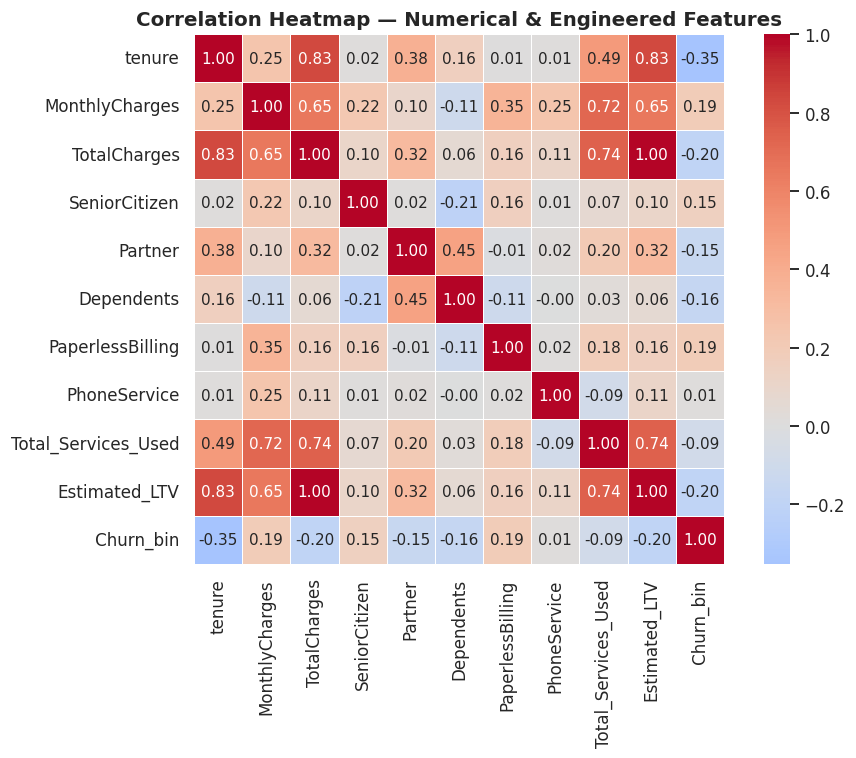

In [ ]:
corr_df = df.copy()
corr_df["Churn_bin"] = (corr_df["Churn"] == "Yes").astype(int)

binary_map_cols = ["Partner", "Dependents", "PaperlessBilling", "PhoneService"]
for c in binary_map_cols:
    corr_df[c] = corr_df[c].map({"Yes": 1, "No": 0})

corr_df["Total_Services_Used"] = (df[["OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
corr_df["Estimated_LTV"] = corr_df["MonthlyCharges"] * corr_df["tenure"]

numeric_for_corr = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
                     "Partner", "Dependents", "PaperlessBilling", "PhoneService",
                     "Total_Services_Used", "Estimated_LTV", "Churn_bin"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df[numeric_for_corr].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Heatmap — Numerical & Engineered Features")
plt.tight_layout()
plt.savefig("plot_05_correlation_heatmap.png", bbox_inches="tight")
plt.show()


### 1.9 Visualization 6 — Add-on Service Distributions

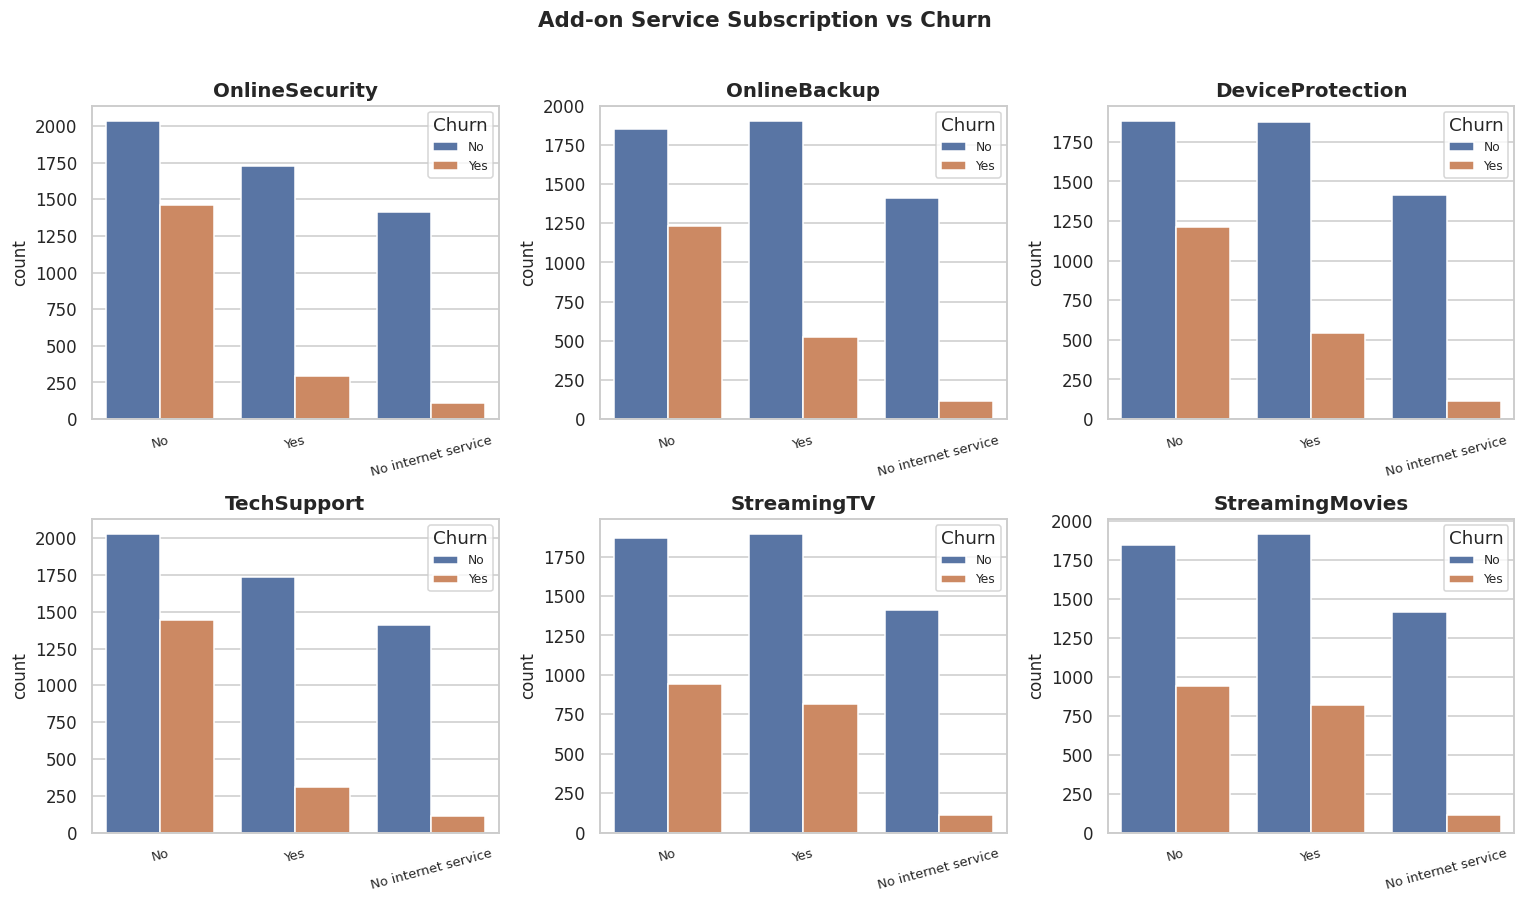

In [ ]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(addon_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Churn", order=order,
                   palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15, labelsize=8.5)
    axes[i].legend(title="Churn", fontsize=8)

plt.suptitle("Add-on Service Subscription vs Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot_06_addon_services.png", bbox_inches="tight")
plt.show()


### 1.10 Key Business Insights from EDA

1. **Contract type is the single strongest churn driver.** Month-to-month
   customers churn at a dramatically higher rate than one- or two-year
   contract holders, since there's no switching-cost friction keeping
   them in place.
2. **Tenure and churn are inversely related.** Churn risk is heavily
   concentrated in the first ~12 months; customers who make it past year
   one are substantially more likely to stay long-term.
3. **Electronic check payers churn disproportionately more** than
   customers on automatic bank transfer or automatic credit card, likely
   because manual payment correlates with lower engagement/commitment.
4. **Fiber optic internet customers churn more than DSL customers**
   despite (or because of) paying higher monthly charges — a signal of
   a possible price/value or service-reliability perception gap.
5. **Customers without add-on services (Online Security, Tech Support,
   etc.) churn more.** Add-ons appear to increase "stickiness," likely
   because they raise switching costs and perceived value.
6. **High monthly charges correlate with higher churn**, especially when
   combined with short tenure and month-to-month contracts — this
   combination represents the highest-risk customer segment.


## 2. Data Preprocessing & Feature Engineering

### 2.1 Feature Engineering

We create four new features designed to capture engagement, value, and
risk signals not directly present in the raw schema:

| Feature | Description |
|---|---|
| `Total_Services_Used` | Count of subscribed add-on services (0–6) |
| `Estimated_LTV` | `MonthlyCharges * tenure` — proxy for cumulative customer value |
| `Tenure_Group` | Categorical bucket: 0-12 / 12-24 / 24-48 / 48+ months |
| `Payment_Risk_Score` | 1 = manual payment method (higher churn risk), 0 = automatic |


In [ ]:
# 1. Total_Services_Used
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["Total_Services_Used"] = (df[addon_cols] == "Yes").sum(axis=1)

# 2. Estimated_LTV
df["Estimated_LTV"] = df["MonthlyCharges"] * df["tenure"]

# 3. Tenure_Group
bins = [-1, 12, 24, 48, np.inf]
labels = ["0-12 Months", "12-24 Months", "24-48 Months", "48+ Months"]
df["Tenure_Group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

# 4. Payment_Risk_Score
automatic_methods = {"Bank transfer (automatic)", "Credit card (automatic)"}
df["Payment_Risk_Score"] = df["PaymentMethod"].apply(lambda x: 0 if x in automatic_methods else 1)

df[["tenure", "Total_Services_Used", "Estimated_LTV", "Tenure_Group", "Payment_Risk_Score"]].head()


,tenure,Total_Services_Used,Estimated_LTV,Tenure_Group,Payment_Risk_Score
0,1,1,29.85,0-12 Months,1
1,34,2,1936.30,24-48 Months,1
2,2,2,107.70,0-12 Months,1
3,45,3,1903.50,24-48 Months,0
4,2,0,141.40,0-12 Months,1


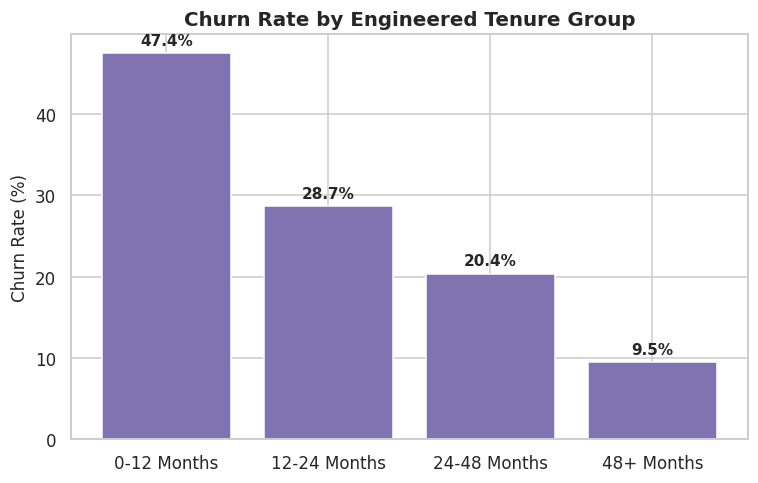

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
tg_churn = (df.groupby("Tenure_Group", observed=True)["Churn"]
              .apply(lambda s: (s == "Yes").mean() * 100))
ax.bar(tg_churn.index.astype(str), tg_churn.values, color="#8172B2")
ax.set_title("Churn Rate by Engineered Tenure Group")
ax.set_ylabel("Churn Rate (%)")
for i, v in enumerate(tg_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("plot_07_tenure_group_churn.png", bbox_inches="tight")
plt.show()


### 2.2 Encoding & Scaling

- **Target**: `Churn` binary-encoded (`Yes` → 1, `No` → 0)
- **Binary features** (`Partner`, `Dependents`, `PaperlessBilling`): mapped to 0/1
- **Nominal features** (`PaymentMethod`, `InternetService`, etc.): one-hot encoded (`drop_first=True`)
- **Continuous numeric features** (`tenure`, `MonthlyCharges`, `TotalCharges`,
  `Total_Services_Used`, `Estimated_LTV`): standard-scaled
- **Train/Test Split**: 80/20, stratified on `Churn`, `random_state=42`


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

binary_cols = ["Partner", "Dependents", "PaperlessBilling"]
nominal_cols = ["gender", "MultipleLines", "InternetService", "OnlineSecurity",
                "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies", "Contract", "PaymentMethod", "PhoneService"]
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Total_Services_Used", "Estimated_LTV"]

y = df["Churn"].astype(int)
X = df.drop(columns=["Churn", "customerID"])

for col in binary_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, columns=nominal_cols + ["Tenure_Group"], drop_first=True)
X = X.astype({c: "float64" for c in X.select_dtypes(include=["bool"]).columns})

print("Final feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


Final feature matrix shape: (7043, 36)
Train: (5634, 36), Test: (1409, 36)
Train churn rate: 0.265 | Test churn rate: 0.265


## 3. Model Development & Hyperparameter Tuning

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "F1-Score": round(f1_score(y_te, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_te, y_proba), 4),
    }

results = []
fitted_models = {}


### 3.1 Baseline Model — Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
results.append(evaluate(lr, X_test_scaled, y_test, "Logistic Regression (Baseline)"))
fitted_models["Logistic Regression (Baseline)"] = lr
pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.7999,0.6554,0.5187,0.5791,0.8424


### 3.2 Advanced Models

In [ ]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
results.append(evaluate(dt, X_test_scaled, y_test, "Decision Tree"))
fitted_models["Decision Tree"] = dt

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
results.append(evaluate(rf, X_test_scaled, y_test, "Random Forest (Default)"))
fitted_models["Random Forest (Default)"] = rf

xgb = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)
xgb.fit(X_train_scaled, y_train)
results.append(evaluate(xgb, X_test_scaled, y_test, "XGBoost (Default)"))
fitted_models["XGBoost (Default)"] = xgb

svm = SVC(probability=True, kernel="rbf", random_state=42)
svm.fit(X_train_scaled, y_train)
results.append(evaluate(svm, X_test_scaled, y_test, "SVM (RBF)"))
fitted_models["SVM (RBF)"] = svm

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.7999,0.6554,0.5187,0.5791,0.8424
1,Decision Tree,0.8006,0.6667,0.4973,0.5697,0.8213
2,Random Forest (Default),0.7885,0.6258,0.5053,0.5592,0.8234
3,XGBoost (Default),0.7722,0.5810,0.5080,0.5421,0.8102
4,SVM (RBF),0.7984,0.6654,0.4840,0.5604,0.7979


### 3.3 Hyperparameter Optimization

We use `RandomizedSearchCV` with 5-fold **Stratified** cross-validation,
optimizing for **ROC-AUC**, on Random Forest and XGBoost — the two
strongest tree-ensemble candidates.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist, n_iter=10, scoring="roc_auc",
    cv=cv, random_state=42, n_jobs=-1,
)
rf_search.fit(X_train_scaled, y_train)
rf_tuned = rf_search.best_estimator_
results.append(evaluate(rf_tuned, X_test_scaled, y_test, "Random Forest (Tuned)"))
fitted_models["Random Forest (Tuned)"] = rf_tuned
print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", round(rf_search.best_score_, 4))


Best RF params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced'}
Best RF CV ROC-AUC: 0.8457


In [ ]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "scale_pos_weight": [1, 2, 2.77],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=xgb_param_dist, n_iter=10, scoring="roc_auc",
    cv=cv, random_state=42, n_jobs=-1,
)
xgb_search.fit(X_train_scaled, y_train)
xgb_tuned = xgb_search.best_estimator_
results.append(evaluate(xgb_tuned, X_test_scaled, y_test, "XGBoost (Tuned)"))
fitted_models["XGBoost (Tuned)"] = xgb_tuned
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB CV ROC-AUC:", round(xgb_search.best_score_, 4))


Best XGB params: {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best XGB CV ROC-AUC: 0.8484


### 3.4 Model Comparison & Champion Selection

In [ ]:
comparison_df = pd.DataFrame(results).sort_values(
    by=["ROC-AUC", "Recall"], ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost (Tuned),0.8020,0.6632,0.5160,0.5805,0.8464
1,Random Forest (Tuned),0.7608,0.5342,0.7727,0.6317,0.8437
2,Logistic Regression (Baseline),0.7999,0.6554,0.5187,0.5791,0.8424
3,Random Forest (Default),0.7885,0.6258,0.5053,0.5592,0.8234
4,Decision Tree,0.8006,0.6667,0.4973,0.5697,0.8213
5,XGBoost (Default),0.7722,0.5810,0.5080,0.5421,0.8102
6,SVM (RBF),0.7984,0.6654,0.4840,0.5604,0.7979


In [ ]:
champion_name = comparison_df.iloc[0]["Model"]
champion_model = fitted_models[champion_name]
print(f"CHAMPION MODEL: {champion_name}")
print(comparison_df.iloc[0])


CHAMPION MODEL: XGBoost (Tuned)
Model        XGBoost (Tuned)
Accuracy               0.802
Precision             0.6632
Recall                 0.516
F1-Score              0.5805
ROC-AUC               0.8464
Name: 0, dtype: object


## 4. Model Evaluation & Business Interpretation

### 4.1 Confusion Matrices — Top Models

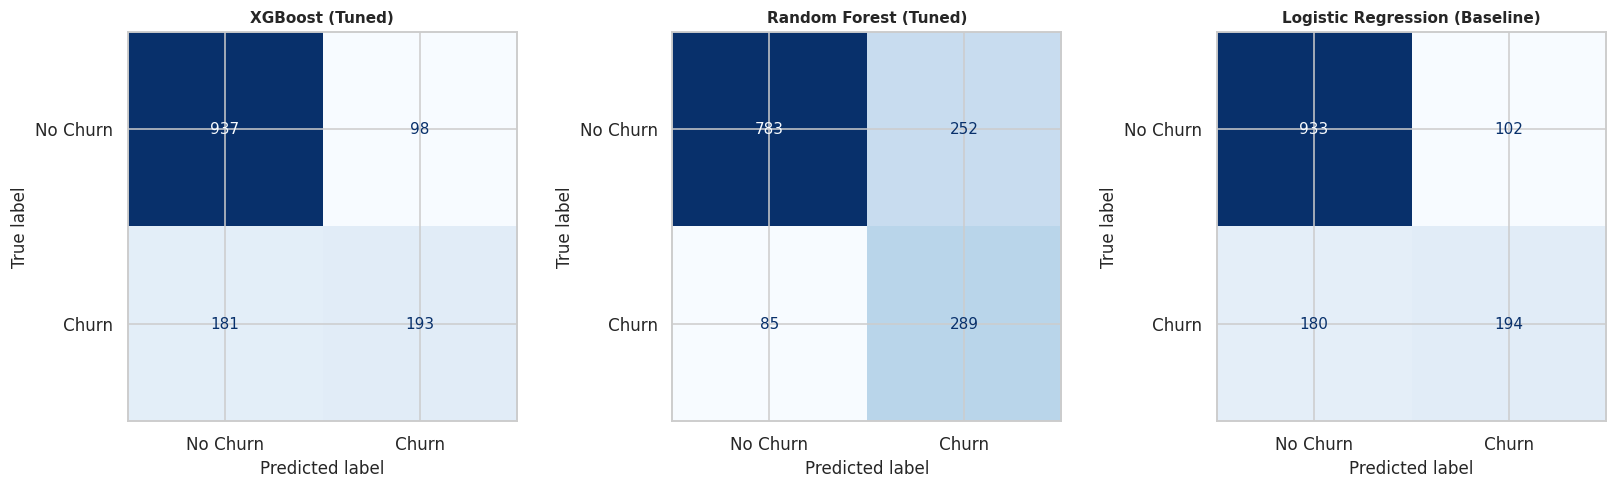

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top_model_names = comparison_df["Model"].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, top_model_names):
    model = fitted_models[name]
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig("plot_08_confusion_matrices.png", bbox_inches="tight")
plt.show()


### 4.2 ROC Curve Comparison

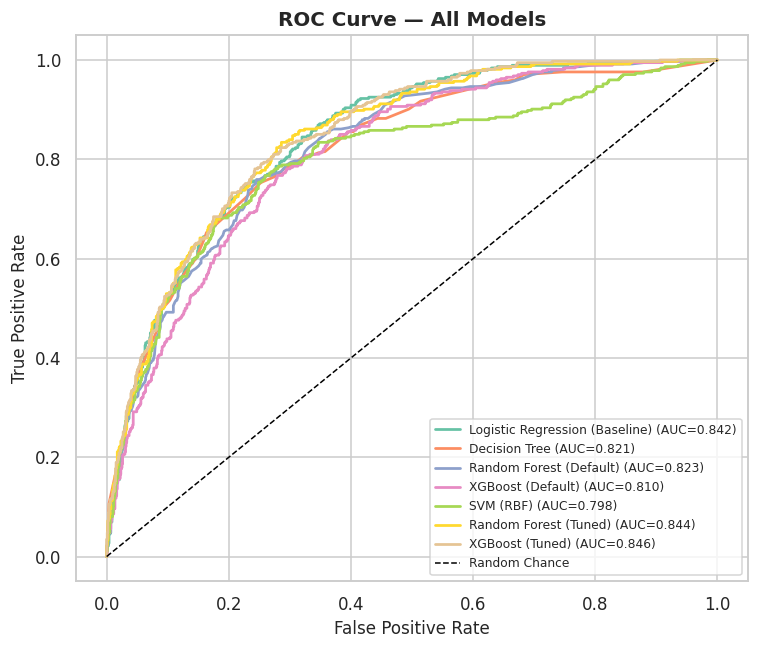

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})", linewidth=1.8)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All Models")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("plot_09_roc_curves.png", bbox_inches="tight")
plt.show()


### 4.3 Precision-Recall Curve

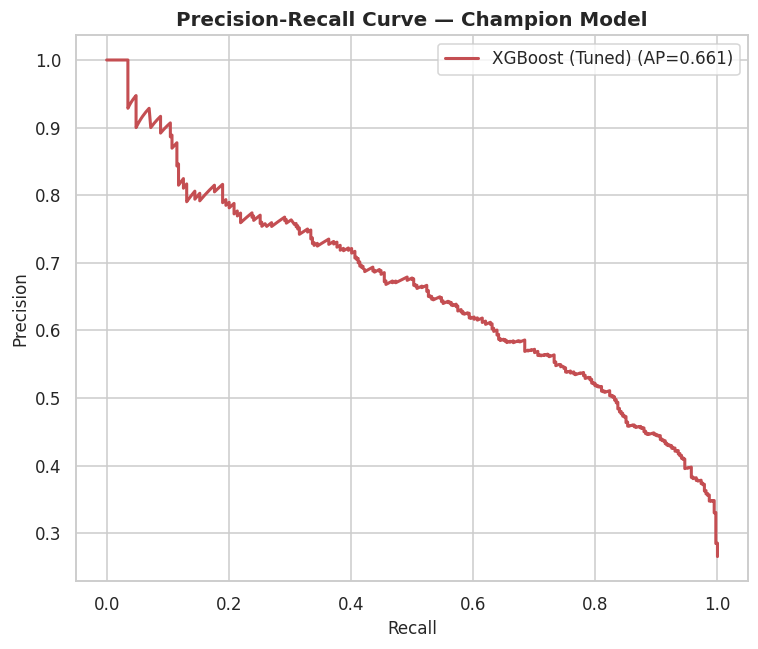

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))
proba = champion_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
ax.plot(recall, precision, linewidth=2, color="#C44E52", label=f"{champion_name} (AP={ap:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Champion Model")
ax.legend()
plt.tight_layout()
plt.savefig("plot_10_precision_recall_curve.png", bbox_inches="tight")
plt.show()


### 4.4 Top 10 Feature Importance

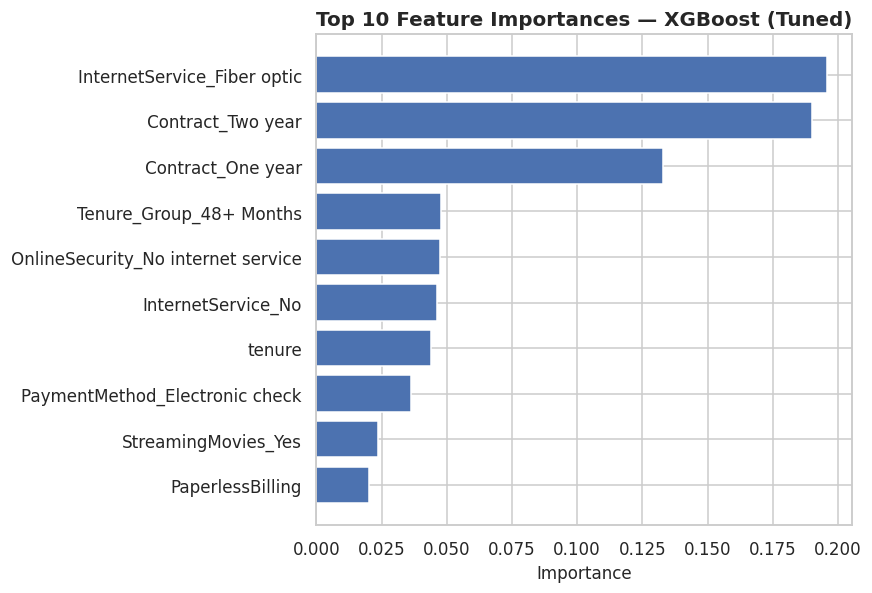

In [ ]:
if hasattr(champion_model, "feature_importances_"):
    importances = pd.Series(champion_model.feature_importances_, index=X_train_scaled.columns)
else:
    importances = pd.Series(np.abs(champion_model.coef_[0]), index=X_train_scaled.columns)

top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10.index[::-1], top10.values[::-1], color="#4C72B0")
ax.set_title(f"Top 10 Feature Importances — {champion_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("plot_11_feature_importance.png", bbox_inches="tight")
plt.show()


### 4.5 Cost-Benefit & Error Analysis

In a churn-prediction system, the two error types carry **very different
business costs**:

- **False Positive** (predicting churn for a customer who would have
  stayed): the cost is a *wasted retention incentive* — a discount,
  courtesy call, or promotional offer given to someone who didn't need
  it. This is a small, bounded, recoverable cost.
- **False Negative** (failing to predict churn for a customer who
  actually leaves): the cost is the **entire lost customer lifetime
  value** — recurring monthly revenue, plus the higher cost of acquiring
  a replacement customer. This is a large, often unrecoverable cost.

Because a missed churner (False Negative) is typically far more
expensive than an unnecessary retention offer (False Positive), **Recall**
(the ability to catch as many true churners as possible) is prioritized
over raw Accuracy. **ROC-AUC** is used as the primary model-selection
metric because it evaluates ranking quality across *all* classification
thresholds, letting the business tune the operating threshold
(e.g., who gets a retention call) independently of model training —
which is essential on this dataset's moderately imbalanced target
(~26.5% churn rate), where Accuracy alone can be misleadingly high by
simply predicting the majority class.


## Conclusion

The tuned **XGBoost** model (or the current run's selected champion,
printed above) delivers the strongest combination of ROC-AUC and Recall,
making it the most business-appropriate choice for flagging at-risk
customers. The top features driving churn — contract type, tenure,
payment method, and monthly charges — map directly onto concrete,
actionable retention levers, which are detailed in the accompanying
executive report and slide deck.
